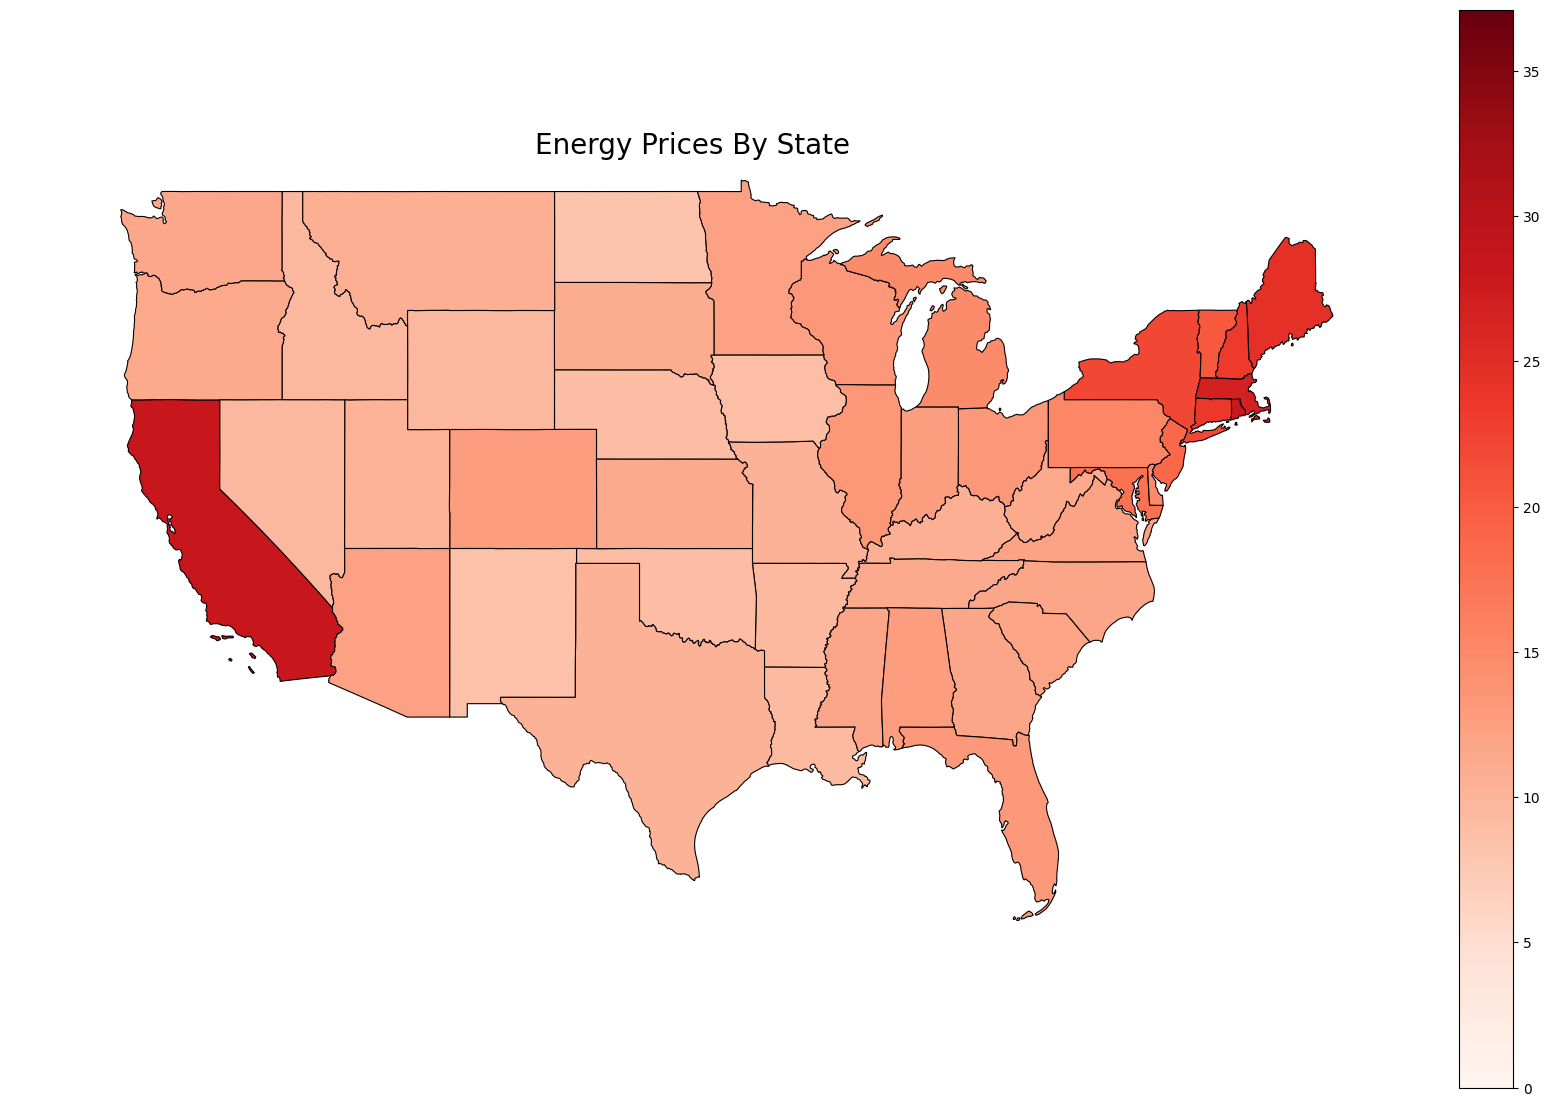

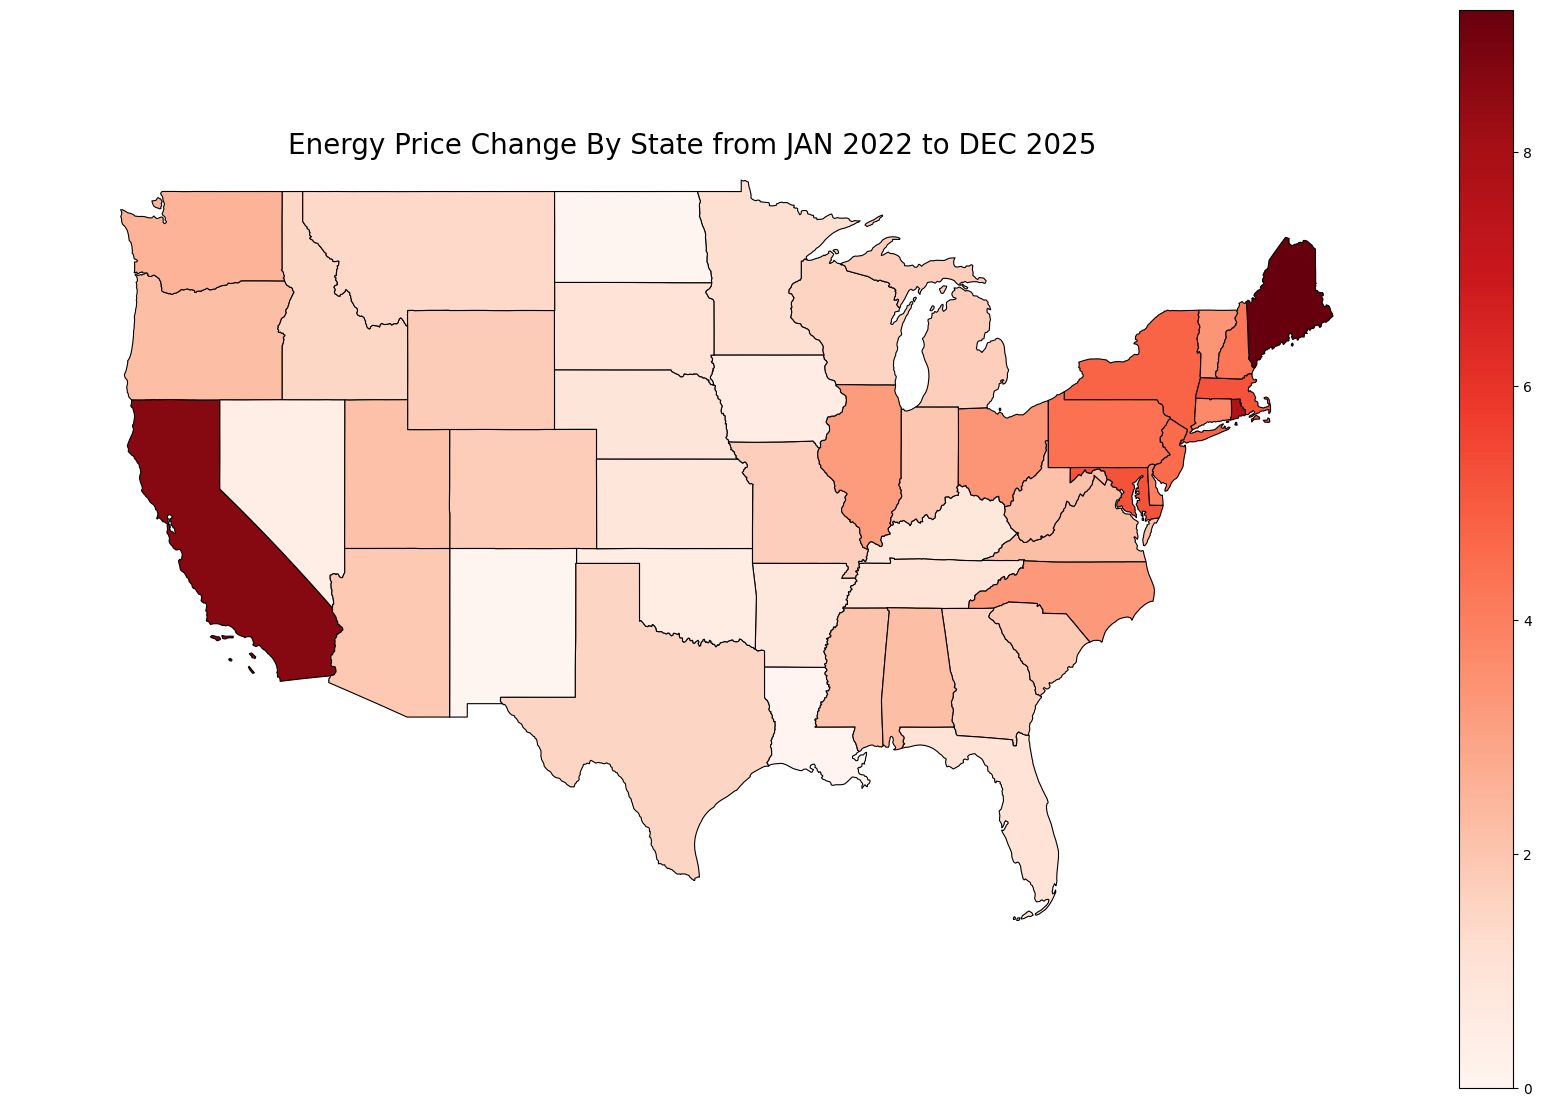

good morning


In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

#This gives us all geometry data we need for the visualizations (.shp, .dbf, .shx, .prj)
usa = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_20m.zip");

#[1] - Data price per state
leanData = pd.read_csv("RecentCleanedData.csv");

#verify price is float
#print(leanData['price'].dtypes);
valueColumn = leanData['price'];

leanStateData = leanData.groupby("stateid")["price"].mean().reset_index();

#this is how we merge our data with the geometry provided by pandas
mergedGeoData = usa.merge(leanStateData, left_on="STUSPS", right_on="stateid");

#generate the map
fig, ax = plt.subplots(1, figsize=(22, 14));
mergedGeoData.plot(
   column="price",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    vmin=0,
    vmax=valueColumn.max()
);

ax.set_title("Energy Prices By State", fontsize=20);
ax.axis("off");

#zoom in
ax.set_xlim(-130, -65);
ax.set_ylim(24, 50);

plt.savefig("EnergyPricesByState.png");
plt.show();


#[2] - Data price change per state
leanData = pd.read_csv("PriceDifference.csv");

#verify price is float
#print(leanData['price'].dtypes);
valueColumn = leanData['price_difference'];

leanStateData = leanData.groupby("stateid")["price_difference"].mean().reset_index();

#this is how we merge our data with the geometry provided by pandas
mergedGeoData = usa.merge(leanStateData, left_on="STUSPS", right_on="stateid");

#generate the map
fig, ax = plt.subplots(1, figsize=(22, 14));
mergedGeoData.plot(
   column="price_difference",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    vmin=0,
    vmax=valueColumn.max()
);

ax.set_title("Energy Price Change By State from JAN 2022 to DEC 2025", fontsize=20);
ax.axis("off");

#zoom in
ax.set_xlim(-130, -65);
ax.set_ylim(24, 50);

plt.savefig("EnergyPriceDifferenceByState.png");
plt.show();



#% difference from Jan 2022 to now (most recent day we have)
print("good morning");